# Week 7, day 1 -- prompts for the fine-tune

The fine-tune eats text, so before any GPU time: decide what the model reads, how long it may be,
and push the result to the Hub where Colab can reach it.

`pricer/prompts.py` holds the layout. The rule that matters: the training prompt and the inference
prompt must be identical up to the final `Price is $`, or the model learns a format it will never see
again.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoTokenizer

from pricer import prompts
from pricer.items import Wine

load_dotenv(override=True)
login(os.environ["HF_TOKEN"])

BASE_MODEL = "Qwen/Qwen2.5-3B"  # open weights, no gate to accept; Llama-3.2-3B works the same way
DATASET = "borjahernandez/wine-pricer"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
train, val, test = Wine.load_local()
print(f"train={len(train):,} val={len(val):,} test={len(test):,}")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


train=49,895 val=2,000 test=2,000


### How long is a wine, in tokens?

median 88, p99 141, max 233


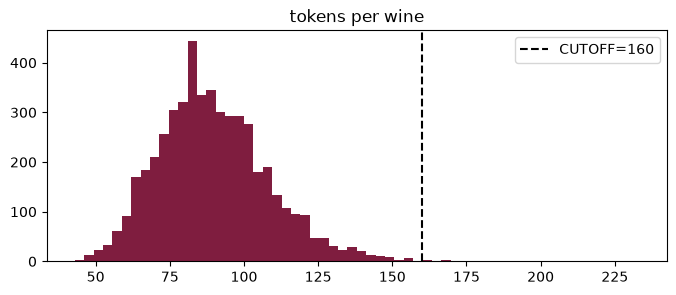

CUTOFF truncates 0.1% of wines


In [2]:
counts = np.array([len(tokenizer.encode(wine.full, add_special_tokens=False)) for wine in train[:5_000]])
print(f"median {np.median(counts):.0f}, p99 {np.percentile(counts, 99):.0f}, max {counts.max()}")
plt.figure(figsize=(8, 3))
plt.hist(counts, bins=60, color="#7f1d3f")
plt.axvline(prompts.CUTOFF, color="black", linestyle="--", label=f"CUTOFF={prompts.CUTOFF}")
plt.legend()
plt.title("tokens per wine")
plt.show()
cut = (counts > prompts.CUTOFF).mean()
print(f"CUTOFF truncates {cut:.1%} of wines")

### Build the prompts

Truncation happens in token space and then backs off to a word boundary, so a wine never ends
mid-word. Every price is rendered as `$42.00` -- one consistent shape, two tokens, easy to parse
back.

In [3]:
prompts.prepare(train, tokenizer)
prompts.prepare(val, tokenizer)
prompts.prepare(test, tokenizer)
print(train[0].prompt)
print("\n--- at inference the model sees:\n")
print(train[0].test_prompt())

How much does this bottle of wine cost, to the nearest dollar?

Vintage: 2010
Variety: Bordeaux-style White Blend
Country: France
Province: Bordeaux
Region: Sauternes
Tasting note: This spicy wine is full of botrytis, giving a dry edge to its rich, honeyed flavors. It has an intense character, hovering between very sweet and dry. Structured with strong acidity, it will be ready to drink from 2018.

Price is $39.00

--- at inference the model sees:

How much does this bottle of wine cost, to the nearest dollar?

Vintage: 2010
Variety: Bordeaux-style White Blend
Country: France
Province: Bordeaux
Region: Sauternes
Tasting note: This spicy wine is full of botrytis, giving a dry edge to its rich, honeyed flavors. It has an intense character, hovering between very sweet and dry. Structured with strong acidity, it will be ready to drink from 2018.

Price is $


### Push to the Hub

Colab pulls this dataset for training. Nothing here is secret, but the tasting notes are Wine
Enthusiast's, so keep the dataset private if you plan to leave it up.

In [4]:
Wine.push_to_hub(DATASET, train, val, test)
print(f"https://huggingface.co/datasets/{DATASET}")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

https://huggingface.co/datasets/borjahernandez/wine-pricer


### Experiment: is the flowery prose worth its tokens?

Rerun this notebook with `use_summary=True` (after `scripts/tasting.py` has filled in the LLM
summaries) and push to a second dataset. Fine-tune on both. The summary is roughly a fifth of the
tokens, so if it scores within noise of the full note, the note is mostly decoration.

In [5]:
# prompts.prepare(train, tokenizer, use_summary=True)   # needs scripts/tasting.py to have run
# Wine.push_to_hub(f"{DATASET}-summaries", train, val, test)